In [ ]:
import pandas as pd

# Load data
df = pd.read_excel('Final Project Data (Titanic)(1).xlsx')
print(df.head())

   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  
3      0            113803  53.1000  C123        S  
4      0            373450   8.0500   NaN        S  


In [ ]:
# 2. Check Shape
print("\n--- Shape ---")
print(f"Rows: {df.shape[0]}, Columns: {df.shape[1]}")

# 3. Check and Fill Missing Values
print("\n--- Missing Values Before ---")
print(df.isnull().sum())

df_cleaned = df.copy()
df_cleaned['Age'] = df_cleaned['Age'].fillna(df_cleaned['Age'].median())
df_cleaned['Embarked'] = df_cleaned['Embarked'].fillna(df_cleaned['Embarked'].mode()[0])
df_cleaned['Cabin'] = df_cleaned['Cabin'].fillna('Unknown')

print("\n--- Missing Values After Cleaning ---")
print(df_cleaned.isnull().sum())

# 4. Check Class Balance
print("\n--- Class Balance ---")
counts = df_cleaned['Survived'].value_counts()
proportions = df_cleaned['Survived'].value_counts(normalize=True)
for cls in counts.index:
    print(f"Class {cls}: {counts[cls]} samples ({proportions[cls]*100:.2f}%)")

# 5. Note on Metric
print("\n--- Conclusion ---")
print("Note: One class (0) has significantly more samples than the other.")
print("Main Metric to use for evaluation: F1-score")

# Save cleaned data
df_cleaned.to_csv('cleaned_titanic_data.csv', index=False)


--- Shape ---
Rows: 891, Columns: 12

--- Missing Values Before ---
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

--- Missing Values After Cleaning ---
PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Cabin          0
Embarked       0
dtype: int64

--- Class Balance ---
Class 0: 549 samples (61.62%)
Class 1: 342 samples (38.38%)

--- Conclusion ---
Note: One class (0) has significantly more samples than the other.
Main Metric to use for evaluation: F1-score


In [ ]:
# STEP 1 TASK 2

In [ ]:
# STEP 1 TASK 2

In [ ]:
from sklearn.model_selection import train_test_split

# 1. تحميل البيانات النظيفة من الخطوة السابقة
df = pd.read_csv('cleaned_titanic_data.csv')

# 2. تحديد الميزات (X) والمستهدف (y)
# قمنا باستبعاد الأعمدة التي لا تفيد النموذج المبدئي (كالاسم ورقم التذكرة)
X_raw = df.drop(columns=['Survived', 'PassengerId', 'Name', 'Ticket', 'Cabin'])

# تحويل الأعمدة النصية (الجنس، بوابة الصعود) إلى أرقام (One-Hot Encoding)
X = pd.get_dummies(X_raw, columns=['Sex', 'Embarked'], drop_first=True)

# تحديد المستهدف (y)
y = df['Survived']

# 3. تقسيم البيانات إلى 80% تدريب و 20% اختبار
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# طباعة أبعاد البيانات للتأكد
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

X_train shape: (712, 8)
X_test shape: (179, 8)


In [ ]:
# STEP 1 TASK 3

In [ ]:
# STEP 1 TASK 3

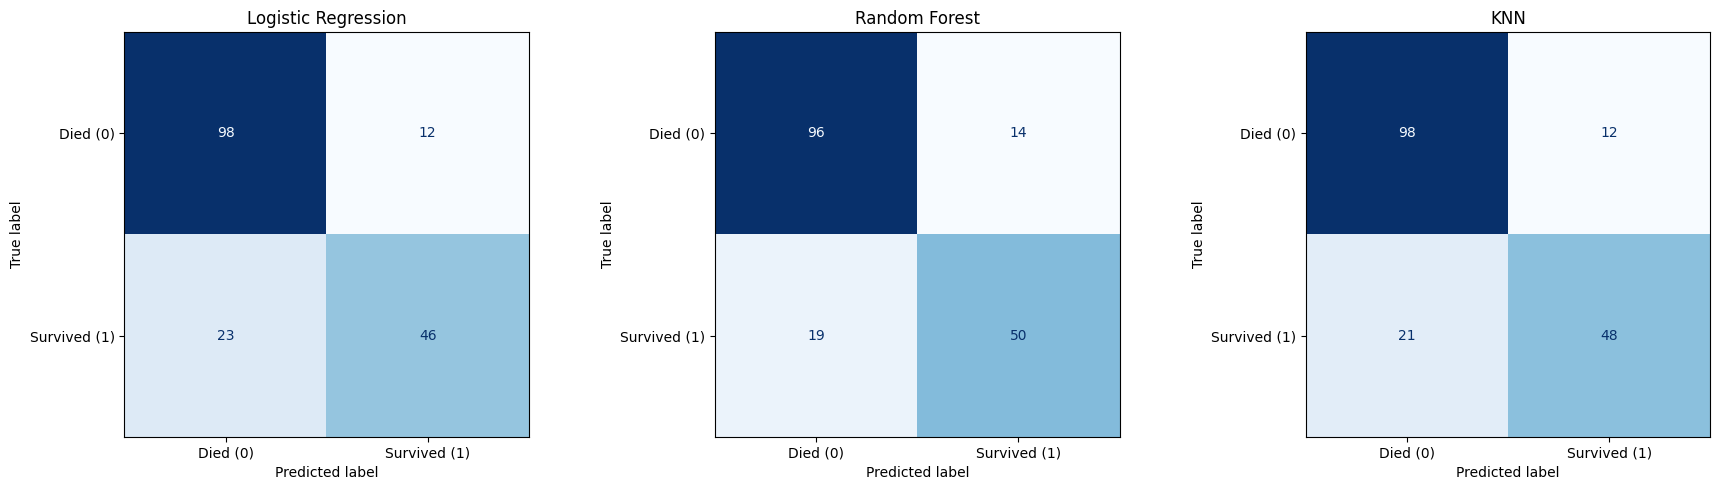

              Model  Accuracy  Precision   Recall  F1-Score
Logistic Regression  0.804469   0.793103 0.666667  0.724409
      Random Forest  0.815642   0.781250 0.724638  0.751880
                KNN  0.815642   0.800000 0.695652  0.744186


In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import pandas as pd

# Scaling is highly required for KNN and Logistic Regression
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test) # Transform only, NO FIT on test!

models = {
    'Logistic Regression': LogisticRegression(random_state=42, max_iter=1000),
    'Random Forest': RandomForestClassifier(random_state=42),
    'KNN': KNeighborsClassifier(n_neighbors=5)
}

results = []
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for idx, (name, model) in enumerate(models.items()):
    # 1. Train
    model.fit(X_train_scaled, y_train)

    # 2. Predict
    y_pred = model.predict(X_test_scaled)

    # 3. Calculate metrics
    results.append({
        'Model': name,
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred),
        'F1-Score': f1_score(y_test, y_pred)
    })

    # 4. Plot Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Died (0)', 'Survived (1)'])
    disp.plot(ax=axes[idx], cmap='Blues', colorbar=False)
    axes[idx].set_title(f'{name}')

plt.tight_layout()
plt.show()

# Print Summary Table
summary_table = pd.DataFrame(results)
print(summary_table.to_string(index=False))

In [ ]:
df_cleaned.to_csv('final_processed_titanic.csv', index=False)

In [ ]:
import pandas as pd
df = pd.read_csv('final_processed_titanic.csv', engine='python')
print(df.head())

   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare    Cabin Embarked  
0      0         A/5 21171   7.2500  Unknown        S  
1      0          PC 17599  71.2833      C85        C  
2      0  STON/O2. 3101282   7.9250  Unknown        S  
3      0            113803  53.1000     C123        S  
4      0            373450   8.0500  Unk

In [ ]:
# STEP 2 TASK 1

In [ ]:
# STEP 2 TASK 1

Epoch 1/35
23/23 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - accuracy: 0.6629 - loss: 0.6467 - val_accuracy: 0.7542 - val_loss: 0.6007
Epoch 2/35
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.7388 - loss: 0.5931 - val_accuracy: 0.7765 - val_loss: 0.5677
Epoch 3/35
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7360 - loss: 0.5675 - val_accuracy: 0.7821 - val_loss: 0.5413
Epoch 4/35
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.7767 - loss: 0.5284 - val_accuracy: 0.7933 - val_loss: 0.5179
Epoch 5/35
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7711 - loss: 0.5263 - val_accuracy: 0.7877 - val_loss: 0.5028
Epoch 6/35
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.7837 - loss: 0.5157 - val_accuracy: 0.7933 - val_loss: 0.4897
Epoch 7/35
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7865 - loss: 0.5112 - val_accuracy: 0.7989 - val_loss: 0.4794
Epoch 8/35
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7781 - loss: 0.4995 - val_accuracy: 0.7989 - val_lo

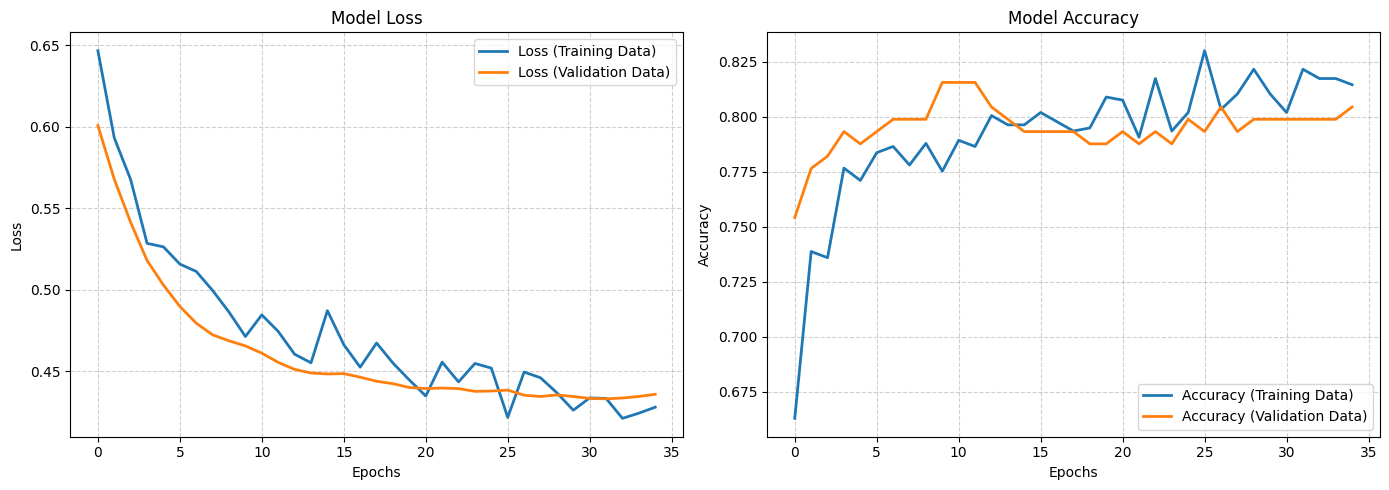

Test Accuracy: 80.45%


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Input

# 1. قراءة وتحضير البيانات المحدثة
df = pd.read_csv('cleaned_titanic_data.csv')
df['Age'] = df['Age'].fillna(df['Age'].median())
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])

X_raw = df.drop(columns=['Survived', 'PassengerId', 'Name', 'Ticket', 'Cabin'])
y = df['Survived']
X = pd.get_dummies(X_raw, columns=['Sex', 'Embarked'], drop_first=True, dtype=int)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train).astype(np.float32)
X_test_scaled = scaler.transform(X_test).astype(np.float32)

y_train = np.array(y_train).astype(np.float32)
y_test = np.array(y_test).astype(np.float32)

# 2. بناء الشبكة العصبية المطلوبة (Neural Network with Keras Dense, ReLU, Sigmoid and Dropout)
tf.random.set_seed(42)
model = Sequential([
    Input(shape=(X_train_scaled.shape[1],)), # Use Input layer to define input shape
    Dense(32, activation='relu'),
    Dropout(0.3),  # إضافة طبقة Dropout لتقليل Overfitting
    Dense(16, activation='relu'),
    Dropout(0.2),  # إضافة طبقة Dropout ثانية
    Dense(1, activation='sigmoid') # استخدام Sigmoid للتصنيف الثنائي
])

# 3. تجميع النموذج
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# 4. التدريب لأكثر من 10 حقبات (Train for at least 10 epochs)
history = model.fit(
    X_train_scaled, y_train,
    epochs=35,
    batch_size=32,
    validation_data=(X_test_scaled, y_test),
    verbose=1
)

# 5. رسم منحنيات الخسارة والدقة للتدريب مقابل التحقق (Plot training vs. validation curves)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# منحنى الخسارة (Loss Curve)
ax1.plot(history.history['loss'], label='Loss (Training Data)', linewidth=2)
ax1.plot(history.history['val_loss'], label='Loss (Validation Data)', linewidth=2)
ax1.set_title('Model Loss')
ax1.set_xlabel('Epochs')
ax1.set_ylabel('Loss')
ax1.legend()
ax1.grid(True, linestyle='--', alpha=0.6)

# منحنى الدقة (Accuracy Curve)
ax2.plot(history.history['accuracy'], label='Accuracy (Training Data)', linewidth=2)
ax2.plot(history.history['val_accuracy'], label='Accuracy (Validation Data)', linewidth=2)
ax2.set_title('Model Accuracy')
ax2.set_xlabel('Epochs')
ax2.set_ylabel('Accuracy')
ax2.legend()
ax2.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

# 6. التقييم النهائي
loss, accuracy = model.evaluate(X_test_scaled, y_test, verbose=0)
print(f"Test Accuracy: {accuracy*100:.2f}%")

In [ ]:
# STEP 2 TASK 2

In [ ]:
# STEP 2 TASK 2

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# 1. تحضير البيانات باستخدام الملف الجاهز والمحفوظ سابقاً
# (تأكد من وجود هذا الملف في نفس المجلد أو قم برفعه لبيئة العمل)
df = pd.read_csv('cleaned_titanic_data.csv')

# Drop irrelevant columns for X_raw before one-hot encoding
X_raw = df.drop(columns=['Survived', 'PassengerId', 'Name', 'Ticket', 'Cabin'])
y = df['Survived']

# One-hot encode categorical features
X = pd.get_dummies(X_raw, columns=['Sex', 'Embarked'], drop_first=True, dtype=int)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train).astype(np.float32)
X_test_scaled = scaler.transform(X_test).astype(np.float32)

y_train_np = np.array(y_train).astype(np.float32)
y_test_np = np.array(y_test).astype(np.float32)

# 2. تقييم النماذج التقليدية
models = {
    'Logistic Regression': LogisticRegression(random_state=42, max_iter=1000),
    'Random Forest': RandomForestClassifier(random_state=42),
    'KNN': KNeighborsClassifier(n_neighbors=5)
}

results = []
for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)
    results.append({
        'Model': name,
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred),
        'F1-Score': f1_score(y_test, y_pred)
    })

# 3. بناء الشبكة العصبية
tf.random.set_seed(42)
nn_model = Sequential([
    Input(shape=(X_train_scaled.shape[1],)), # Added Input layer to address Keras UserWarning
    Dense(64, activation='relu'),
    Dropout(0.3),
    Dense(32, activation='relu'),
    Dropout(0.2),
    Dense(16, activation='relu'),
    Dropout(0.1),
    Dense(1, activation='sigmoid')
])

nn_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
nn_model.fit(X_train_scaled, y_train_np, epochs=60, batch_size=32, verbose=0)

# 4. تقييم الشبكة العصبية على بيانات الاختبار
y_pred_nn_prob = nn_model.predict(X_test_scaled)
y_pred_nn = (y_pred_nn_prob > 0.5).astype(int).flatten()

results.append({
    'Model': 'Neural Network',
    'Accuracy': accuracy_score(y_test, y_pred_nn),
    'Precision': precision_score(y_test, y_pred_nn),
    'Recall': recall_score(y_test, y_pred_nn),
    'F1-Score': f1_score(y_test, y_pred_nn)
})

# عرض جدول الملخص النهائي
summary_df = pd.DataFrame(results)
print(summary_df.to_string(index=False))

6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
              Model  Accuracy  Precision   Recall  F1-Score
Logistic Regression  0.804469   0.793103 0.666667  0.724409
      Random Forest  0.815642   0.781250 0.724638  0.751880
                KNN  0.815642   0.800000 0.695652  0.744186
     Neural Network  0.810056   0.818182 0.652174  0.725806
